In [3]:
!pip install pyspark

  Using cached pyspark-4.0.2.tar.gz (434.2 MB)
  Created wheel for pyspark: filename=pyspark-4.0.2-py2.py3-none-any.whl size=434827123 sha256=d1240851455d7b41bd8b94fc44c1052ffe38a4a56924dd305bc5f3355891835d
  Stored in directory: c:\users\abhi_\appdata\local\pip\cache\wheels\43\2f\d1\97fb12783fd5d209434848fbd4b897874d7bb2679e7dfc0db3
Successfully built pyspark


In [2]:
!pip install findspark

In [4]:
import findspark
findspark.init()

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Start Spark Session
spark = SparkSession.builder \
    .appName("NYC_Taxi_BI_Pipeline") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("✅ Spark Session Started")
print(f"Spark Version: {spark.version}")

# Load Data
df = spark.read.parquet("yellow_tripdata_2023-01.parquet")
print(f"✅ Loaded {df.count():,} records")
print(f"Columns: {len(df.columns)}")
df.printSchema()

C:\Users\abhi_\anaconda3\anaconda\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\abhi_\anaconda3\anaconda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


✅ Spark Session Started
Spark Version: 4.0.2
✅ Loaded 3,066,766 records
Columns: 19
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



In [6]:
# Clean data - remove bad records
df = df.filter(
    (col("fare_amount") > 0) &
    (col("trip_distance") > 0) &
    (col("tpep_pickup_datetime").isNotNull()) &
    (col("tpep_dropoff_datetime").isNotNull()) &
    (col("passenger_count") > 0) &
    (col("trip_distance") < 100) &  # remove outliers
    (col("fare_amount") < 500)       # remove outliers
)

print(f"✅ Clean records: {df.count():,}")

# Feature Engineering
df = df.withColumn("trip_duration_min",
        round((unix_timestamp("tpep_dropoff_datetime") - 
               unix_timestamp("tpep_pickup_datetime")) / 60, 2)) \
       .withColumn("trip_speed_mph",
        when(col("trip_duration_min") > 0,
             round(col("trip_distance") / 
                   (col("trip_duration_min") / 60), 2)).otherwise(0)) \
       .withColumn("fare_per_mile",
        round(col("fare_amount") / col("trip_distance"), 2)) \
       .withColumn("pickup_hour",
        hour("tpep_pickup_datetime")) \
       .withColumn("pickup_dayofweek",
        dayofweek("tpep_pickup_datetime")) \
       .withColumn("is_weekend",
        when(col("pickup_dayofweek").isin([1,7]), "Weekend")
        .otherwise("Weekday")) \
       .withColumn("is_peak_hour",
        when((col("pickup_hour").between(7,9)) | 
             (col("pickup_hour").between(17,19)), "Peak")
        .otherwise("Off-Peak")) \
       .withColumn("revenue",
        round(col("fare_amount") + col("tip_amount") + 
              col("tolls_amount"), 2))

print("✅ Feature Engineering Done!")
print(f"New columns added: trip_duration_min, trip_speed_mph, fare_per_mile,")
print(f"pickup_hour, is_weekend, is_peak_hour, revenue")

# Register as SQL table
df.createOrReplaceTempView("taxi_trips")
print("✅ SQL Table Registered!")

✅ Clean records: 2,884,180
✅ Feature Engineering Done!
New columns added: trip_duration_min, trip_speed_mph, fare_per_mile,
pickup_hour, is_weekend, is_peak_hour, revenue
✅ SQL Table Registered!


In [7]:
print("=" * 50)
print("ANALYSIS 1: Revenue by Hour of Day")
print("=" * 50)

hourly = spark.sql("""
    SELECT 
        pickup_hour,
        COUNT(*) as trip_count,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(SUM(revenue), 2) as total_revenue,
        ROUND(AVG(trip_distance), 2) as avg_distance,
        ROUND(AVG(trip_speed_mph), 2) as avg_speed_mph
    FROM taxi_trips
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""")
hourly.show(24)

print("=" * 50)
print("ANALYSIS 2: Peak vs Off-Peak Performance")
print("=" * 50)

spark.sql("""
    SELECT 
        is_peak_hour,
        is_weekend,
        COUNT(*) as trip_count,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(SUM(revenue), 2) as total_revenue,
        ROUND(AVG(trip_duration_min), 2) as avg_duration_min
    FROM taxi_trips
    GROUP BY is_peak_hour, is_weekend
    ORDER BY is_peak_hour, is_weekend
""").show()

print("=" * 50)
print("ANALYSIS 3: Top 10 Pickup Zones by Revenue")
print("=" * 50)

spark.sql("""
    SELECT 
        PULocationID,
        COUNT(*) as trip_count,
        ROUND(SUM(revenue), 2) as total_revenue,
        ROUND(AVG(fare_per_mile), 2) as avg_fare_per_mile,
        ROUND(AVG(trip_distance), 2) as avg_distance
    FROM taxi_trips
    GROUP BY PULocationID
    ORDER BY total_revenue DESC
    LIMIT 10
""").show()

print("=" * 50)
print("ANALYSIS 4: Window Functions - Rolling Revenue Rank")
print("=" * 50)

spark.sql("""
    SELECT 
        pickup_hour,
        is_peak_hour,
        trip_count,
        total_revenue,
        RANK() OVER (ORDER BY total_revenue DESC) as revenue_rank,
        ROUND(SUM(total_revenue) OVER (ORDER BY pickup_hour 
              ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 2) 
              as cumulative_revenue
    FROM (
        SELECT 
            pickup_hour,
            is_peak_hour,
            COUNT(*) as trip_count,
            ROUND(SUM(revenue), 2) as total_revenue
        FROM taxi_trips
        GROUP BY pickup_hour, is_peak_hour
    )
    ORDER BY pickup_hour
""").show(24)

ANALYSIS 1: Revenue by Hour of Day
+-----------+----------+--------+-------------+------------+-------------+
|pickup_hour|trip_count|avg_fare|total_revenue|avg_distance|avg_speed_mph|
+-----------+----------+--------+-------------+------------+-------------+
|          0|     79566|    19.8|   1891540.12|        4.03|        17.24|
|          1|     55565|   17.82|   1185800.85|        3.49|        16.43|
|          2|     38730|   16.71|     769834.4|        3.22|        15.92|
|          3|     25053|   17.74|    528411.26|        3.51|         17.4|
|          4|     15835|   22.22|    419454.02|        4.67|        21.89|
|          5|     16141|   26.46|    512479.39|        5.97|        21.36|
|          6|     39942|   22.12|   1059599.01|        4.78|        17.55|
|          7|     79551|   18.91|   1812099.39|        3.68|        14.35|
|          8|    107899|   17.42|   2269831.12|        3.07|        12.31|
|          9|    122644|   17.61|   2615843.57|        3.09|     

In [8]:
print("=" * 50)
print("ANALYSIS 5: Fare Anomaly Detection (Z-Score)")
print("=" * 50)

spark.sql("""
    WITH stats AS (
        SELECT 
            AVG(fare_amount) as mean_fare,
            STDDEV(fare_amount) as std_fare
        FROM taxi_trips
    ),
    scored AS (
        SELECT 
            fare_amount,
            trip_distance,
            pickup_hour,
            is_peak_hour,
            revenue,
            ROUND((fare_amount - mean_fare) / std_fare, 2) as z_score
        FROM taxi_trips, stats
    )
    SELECT * FROM scored
    WHERE ABS(z_score) > 3
    ORDER BY z_score DESC
    LIMIT 10
""").show()

print("=" * 50)
print("ANALYSIS 6: Driver Utilization by Day & Hour")
print("=" * 50)

spark.sql("""
    SELECT 
        pickup_dayofweek,
        is_peak_hour,
        COUNT(*) as trip_count,
        ROUND(AVG(trip_duration_min), 2) as avg_duration,
        ROUND(AVG(revenue), 2) as avg_revenue_per_trip,
        ROUND(SUM(revenue), 2) as total_revenue
    FROM taxi_trips
    GROUP BY pickup_dayofweek, is_peak_hour
    ORDER BY pickup_dayofweek, is_peak_hour
""").show(14)

print("=" * 50)
print("ANALYSIS 7: Revenue Per Mile by Payment Type")
print("=" * 50)

spark.sql("""
    SELECT 
        payment_type,
        COUNT(*) as trip_count,
        ROUND(AVG(fare_per_mile), 2) as avg_fare_per_mile,
        ROUND(AVG(tip_amount), 2) as avg_tip,
        ROUND(SUM(revenue), 2) as total_revenue,
        ROUND(AVG(trip_distance), 2) as avg_distance
    FROM taxi_trips
    GROUP BY payment_type
    ORDER BY total_revenue DESC
""").show()

print("=" * 50)
print("ANALYSIS 8: Top Pickup→Dropoff Corridors")
print("=" * 50)

spark.sql("""
    SELECT 
        PULocationID,
        DOLocationID,
        COUNT(*) as trip_count,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(SUM(revenue), 2) as total_revenue
    FROM taxi_trips
    GROUP BY PULocationID, DOLocationID
    ORDER BY trip_count DESC
    LIMIT 10
""").show()

ANALYSIS 5: Fare Anomaly Detection (Z-Score)
+-----------+-------------+-----------+------------+-------+-------+
|fare_amount|trip_distance|pickup_hour|is_peak_hour|revenue|z_score|
+-----------+-------------+-----------+------------+-------+-------+
|      497.9|        71.63|         15|    Off-Peak|  497.9|  28.19|
|      497.2|        87.53|         16|    Off-Peak| 503.75|  28.15|
|      496.5|        80.96|         11|    Off-Peak| 503.05|  28.11|
|      495.1|        68.17|         15|    Off-Peak|  495.1|  28.02|
|      483.2|         78.2|          6|    Off-Peak|  483.2|  27.32|
|      480.0|        58.96|         22|    Off-Peak|  519.3|  27.14|
|      472.7|        72.61|         15|    Off-Peak|  477.7|  26.71|
|      472.0|         77.4|         17|        Peak|  543.3|  26.67|
|      466.0|        82.04|         17|        Peak|  496.3|  26.31|
|      459.4|        72.14|          3|    Off-Peak| 465.95|  25.93|
+-----------+-------------+-----------+------------+------

In [9]:
print("Exporting summary tables for Power BI dashboard...")

# Export 1: Hourly KPIs
hourly_pd = spark.sql("""
    SELECT 
        pickup_hour,
        COUNT(*) as trip_count,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(SUM(revenue), 2) as total_revenue,
        ROUND(AVG(trip_distance), 2) as avg_distance,
        ROUND(AVG(trip_speed_mph), 2) as avg_speed_mph,
        is_peak_hour
    FROM taxi_trips
    GROUP BY pickup_hour, is_peak_hour
    ORDER BY pickup_hour
""").toPandas()
hourly_pd.to_csv("summary_hourly_kpis.csv", index=False)
print(f"✅ Hourly KPIs exported: {len(hourly_pd)} rows")

# Export 2: Zone KPIs
zone_pd = spark.sql("""
    SELECT 
        PULocationID,
        COUNT(*) as trip_count,
        ROUND(SUM(revenue), 2) as total_revenue,
        ROUND(AVG(fare_per_mile), 2) as avg_fare_per_mile,
        ROUND(AVG(trip_distance), 2) as avg_distance
    FROM taxi_trips
    GROUP BY PULocationID
    ORDER BY total_revenue DESC
""").toPandas()
zone_pd.to_csv("summary_zone_kpis.csv", index=False)
print(f"✅ Zone KPIs exported: {len(zone_pd)} rows")

# Export 3: Peak vs Off-Peak
peak_pd = spark.sql("""
    SELECT 
        is_peak_hour,
        is_weekend,
        COUNT(*) as trip_count,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(SUM(revenue), 2) as total_revenue,
        ROUND(AVG(trip_duration_min), 2) as avg_duration_min
    FROM taxi_trips
    GROUP BY is_peak_hour, is_weekend
    ORDER BY is_peak_hour, is_weekend
""").toPandas()
peak_pd.to_csv("summary_peak_offpeak.csv", index=False)
print(f"✅ Peak/Off-Peak exported: {len(peak_pd)} rows")

# Export 4: Payment Analysis
payment_pd = spark.sql("""
    SELECT 
        payment_type,
        COUNT(*) as trip_count,
        ROUND(AVG(fare_per_mile), 2) as avg_fare_per_mile,
        ROUND(AVG(tip_amount), 2) as avg_tip,
        ROUND(SUM(revenue), 2) as total_revenue
    FROM taxi_trips
    GROUP BY payment_type
    ORDER BY total_revenue DESC
""").toPandas()
payment_pd.to_csv("summary_payment_analysis.csv", index=False)
print(f"✅ Payment Analysis exported: {len(payment_pd)} rows")

# Export 5: Top Corridors
corridor_pd = spark.sql("""
    SELECT 
        PULocationID,
        DOLocationID,
        COUNT(*) as trip_count,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(SUM(revenue), 2) as total_revenue
    FROM taxi_trips
    GROUP BY PULocationID, DOLocationID
    ORDER BY trip_count DESC
    LIMIT 50
""").toPandas()
corridor_pd.to_csv("summary_top_corridors.csv", index=False)
print(f"✅ Top Corridors exported: {len(corridor_pd)} rows")

Exporting summary tables for Power BI dashboard...
✅ Hourly KPIs exported: 24 rows
✅ Zone KPIs exported: 254 rows
✅ Peak/Off-Peak exported: 4 rows
✅ Payment Analysis exported: 4 rows
✅ Top Corridors exported: 50 rows


In [3]:
import pandas as pd

# Load processed analytics tables
hourly_pd = pd.read_csv("summary_hourly_kpis.csv")
zone_pd = pd.read_csv("summary_zone_kpis.csv")
peak_pd = pd.read_csv("summary_peak_offpeak.csv")

print("Data loaded successfully!")

C:\Users\abhi_\anaconda3\anaconda\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\abhi_\anaconda3\anaconda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


Data loaded successfully!


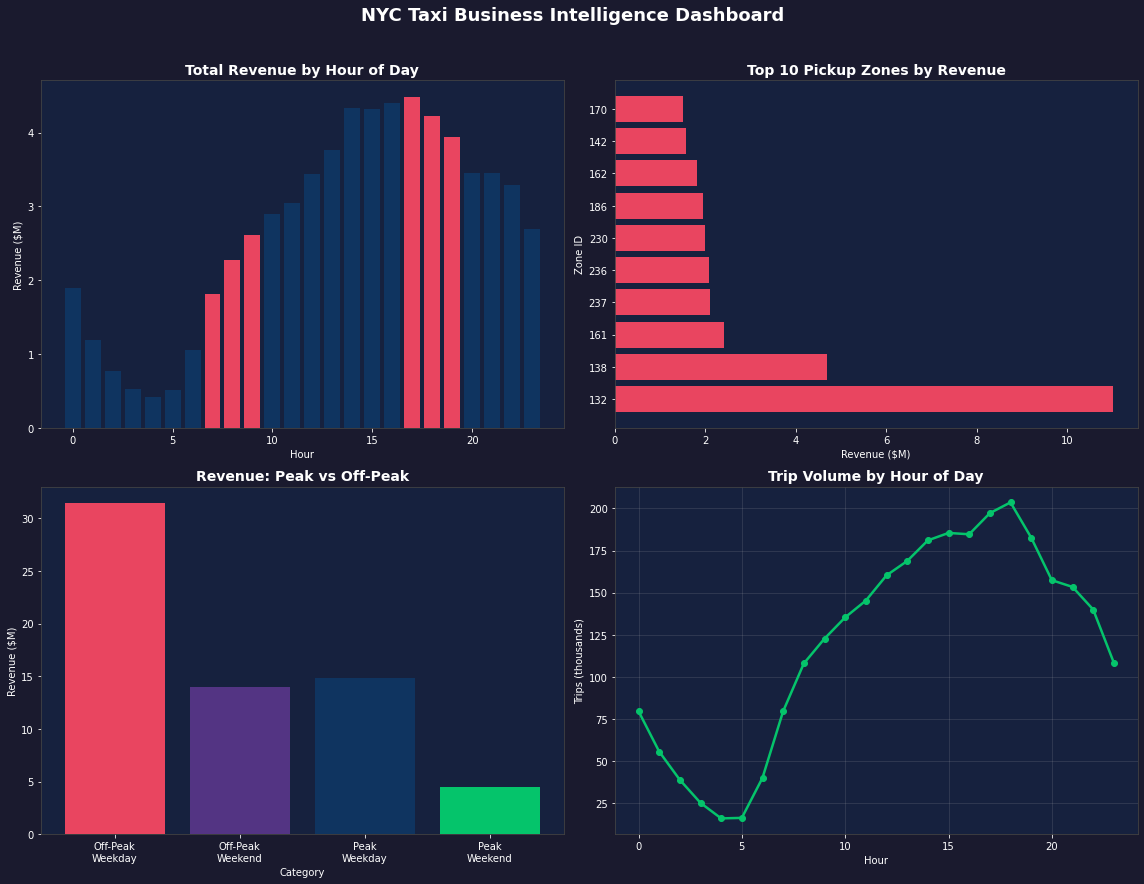

✅ Dashboard preview saved!


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#1a1a2e')

for ax in axes.flatten():
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

# Chart 1: Revenue by Hour
axes[0,0].bar(hourly_pd['pickup_hour'], 
              hourly_pd['total_revenue']/1e6,
              color=['#e94560' if x == 'Peak' 
                     else '#0f3460' 
                     for x in hourly_pd['is_peak_hour']])
axes[0,0].set_title('Total Revenue by Hour of Day', 
                     fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Revenue ($M)')

# Chart 2: Top 10 Zones
top10 = zone_pd.head(10)
axes[0,1].barh(top10['PULocationID'].astype(str), 
               top10['total_revenue']/1e6,
               color='#e94560')
axes[0,1].set_title('Top 10 Pickup Zones by Revenue', 
                     fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Revenue ($M)')
axes[0,1].set_ylabel('Zone ID')

# Chart 3: Peak vs Off-Peak
labels = [f"{r['is_peak_hour']}\n{r['is_weekend']}" 
          for _, r in peak_pd.iterrows()]
axes[1,0].bar(labels, 
              peak_pd['total_revenue']/1e6,
              color=['#e94560','#533483','#0f3460','#05c46b'])
axes[1,0].set_title('Revenue: Peak vs Off-Peak', 
                     fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Revenue ($M)')

# Chart 4: Trip Count by Hour
axes[1,1].plot(hourly_pd['pickup_hour'], 
               hourly_pd['trip_count']/1e3,
               color='#05c46b', linewidth=2.5, marker='o')
axes[1,1].set_title('Trip Volume by Hour of Day', 
                     fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Trips (thousands)')
axes[1,1].grid(True, alpha=0.2)

plt.suptitle('NYC Taxi Business Intelligence Dashboard', 
             fontsize=18, fontweight='bold', 
             color='white', y=1.02)
plt.tight_layout()
plt.savefig('dashboard_preview.png', 
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("✅ Dashboard preview saved!")

In [16]:
# Install Snowflake connector
!pip install snowflake-connector-python pandas

import snowflake.connector
import pandas as pd

# Connect to Snowflake

conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse="COMPUTE_WH",
    database="nyc_taxi_db",
    schema="taxi_analytics"
)

print("✅ Connected to Snowflake!")

# Run analytical queries directly from Python
cursor = conn.cursor()

# Query 1: Peak hour revenue ranking
cursor.execute("""
    SELECT 
        pickup_hour,
        is_peak_hour,
        total_revenue,
        RANK() OVER (ORDER BY total_revenue DESC) as revenue_rank
    FROM hourly_kpis
    ORDER BY pickup_hour
""")
hourly_snow = pd.DataFrame(cursor.fetchall(), 
                           columns=[x[0] for x in cursor.description])
print("✅ Peak Hour Revenue Analysis:")
print(hourly_snow.head(10))

# Query 2: Peak vs Off-Peak summary
cursor.execute("""
    SELECT 
        is_peak_hour,
        SUM(trip_count) as total_trips,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(AVG(avg_fare), 2) as avg_fare
    FROM peak_analysis
    GROUP BY is_peak_hour
    ORDER BY is_peak_hour
""")
peak_snow = pd.DataFrame(cursor.fetchall(),
                         columns=[x[0] for x in cursor.description])
print("\n✅ Peak vs Off-Peak Summary:")
print(peak_snow)

# Query 3: Top 5 zones
cursor.execute("""
    SELECT * FROM zone_kpis
    ORDER BY total_revenue DESC
    LIMIT 5
""")
zone_snow = pd.DataFrame(cursor.fetchall(),
                         columns=[x[0] for x in cursor.description])
print("\n✅ Top 5 Revenue Zones:")
print(zone_snow)

conn.close()
print("\n✅ Snowflake queries complete!")

✅ Connected to Snowflake!
✅ Peak Hour Revenue Analysis:
   PICKUP_HOUR IS_PEAK_HOUR  TOTAL_REVENUE  REVENUE_RANK
0            0     Off-Peak     1891540.12            17
1            1     Off-Peak     1185800.85            19
2            2     Off-Peak      769834.40            21
3            3     Off-Peak      528411.26            22
4            4     Off-Peak      419454.02            24
5            5     Off-Peak      512479.39            23
6            6     Off-Peak     1059599.01            20
7            7         Peak     1812099.39            18
8            8         Peak     2269831.12            16
9            9         Peak     2615843.57            15

✅ Peak vs Off-Peak Summary:
  IS_PEAK_HOUR  TOTAL_TRIPS  TOTAL_REVENUE  AVG_FARE
0     Off-Peak      1990581    45453748.17     18.77
1         Peak       893599    19351781.09     18.23

✅ Top 5 Revenue Zones:
   PULOCATIONID  TRIP_COUNT  TOTAL_REVENUE  AVG_FARE_PER_MILE  AVG_DISTANCE
0           132      152105  